## Modelo pré-treinado Stable Diffusion

In [3]:
import keras_cv
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import warnings
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import time
from IPython.display import clear_output
from tensorflow.keras.models import load_model
import numpy as np
from PIL import Image
import math
from tensorflow import keras


warnings.filterwarnings('ignore')


2025-02-07 17:22:23.888983: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-07 17:22:24.330459: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-07 17:22:24.330626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-07 17:22:24.356761: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-07 17:22:24.490271: I tensorflow/core/platform/cpu_feature_guar

Using TensorFlow backend


In [4]:
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


In [5]:
images = model.text_to_image(
    "Humanoid cat wearing golden jeans, dark fantasy art, "
    "high quality, highly detailed, elegant, sharp focus, "
    "concept art, character concepts, digital painting, mystery, adventure",
    batch_size=3,
)

2025-02-07 17:22:35.999921: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fda08031640 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-02-07 17:22:35.999966: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2025-02-07 17:22:36.093392: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738948958.523588   16110 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-02-07 17:22:38.529187: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2025-02-07 17:23:18.426498: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window = f32[3,2,2,32,1]{4,3,2,1,0} reduce-wind

198180272/198180272 [==============================] - 1s 0us/step


2025-02-07 17:51:42.797358: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 16s:

  %reduce-window.35 = f32[3,4,4,32,1]{4,3,2,1,0} reduce-window(f32[3,128,128,32,16]{4,3,2,1,0} %broadcast.133, f32[] %constant.659), window={size=1x32x32x1x16 stride=1x32x32x1x16}, to_apply=%decoder_resnet_block_5_group_normalization_72_weighted_moments_sum_of_weights-reduction.661

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-02-07 17:51:44.314496: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 17.517228645s
Constant folding an instruction is taking > 16s:

  %r

In [6]:
def plot_images(images):
    plt.figure(figsize=(20, 20))
    for i in range(len(images)):
        ax = plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i])
        plt.axis("off")

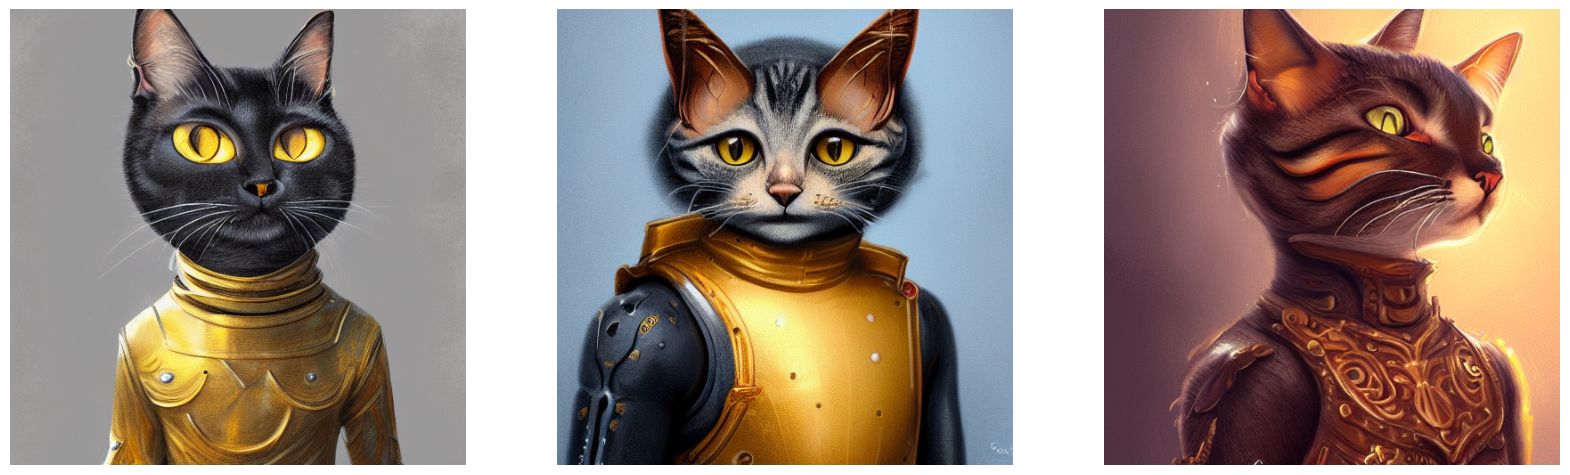

In [7]:
plot_images(images)

## Gerando animações com o Stable Difusion

In [8]:
keras.mixed_precision.set_global_policy("mixed_float16")

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


In [9]:
model = keras_cv.models.StableDiffusion(jit_compile=True)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


In [10]:
prompt_1 = "Panda wearing a blue hat, dark fantasy art, "
prompt_2 = "Cat wearing a blue hat, dark fantasy art, "
interpolation_steps = 5

encoding_1 = tf.squeeze(model.encode_text(prompt_1))
encoding_2 = tf.squeeze(model.encode_text(prompt_2))

interpolated_encodings = tf.linspace(encoding_1, encoding_2, interpolation_steps)

# Show the size of the latent manifold
print(f"Encoding shape: {encoding_1.shape}")

Encoding shape: (77, 768)


In [1]:
seed = 454
noise = tf.random.normal((512 // 8, 512 // 8, 4), seed=seed)

images = model.generate_image(
    interpolated_encodings,
    batch_size=interpolation_steps,
    diffusion_noise=noise,
)

NameError: name 'tf' is not defined

In [ ]:
def export_as_gif(filename, images, frames_per_second=10, rubber_band=False):
    if rubber_band:
        images += images[2:-1][::-1]
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )

In [ ]:
export_as_gif(
    "panda-cat.gif",
    [Image.fromarray(img) for img in images],
    frames_per_second=2,
    rubber_band=True,
)

In [ ]:
from IPython.display import Image as IImage
IImage("panda-cat.gif")

#### Interpolação manual dos resultados

#### Criando um caminho circular com ruído

In [ ]:
interpolation_steps = 150
batch_size = 3
batches = interpolation // batch_size

interpolated_encodings = tf.linspace(encoding_1, encoding_2, interpolation_steps)
batched_encodings = tf.split(interpolated_encodings, batches)

images = []

for batch in range(batches):
  images += [
      Image.fromarray(img)
      for img in model.generate_image(
          batched_encodings[batch], 
          batch_size=batch_size,
          num_steps = 25,
          diffusion_noise = noise
      )
  ]
  
  export_as_gif(
    "panda-cat-fino.gif", images, rubber_band= True
)

In [ ]:
seed = 454
tf.random.set_seed(seed)

prompt = "A majestic cat wearing an ornate golden hat, surrounded by floating orbs of light, in a dark illuminist painting, high detail, cinematic lighting, surreal background, elegant fur texture"
encoding = tf.squeeze(model.encode_text(prompt))

walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size

noise = tf.random.normal((512 // 8, 512 // 8, 4), seed=seed)  # Ruído inicial fixo

# Gerando ruídos circulares com a mesma seed
walk_noise_x = tf.random.normal(noise.shape, dtype="float64", seed=seed)
walk_noise_y = tf.random.normal(noise.shape, dtype="float64", seed=seed)

# Caminhada circular usando coseno e seno
walk_scale_x = tf.cos(tf.linspace(0, 4, walk_steps) * math.pi)
walk_scale_y = tf.sin(tf.linspace(0, 4, walk_steps) * math.pi)

# Ruído circular aplicado
noise_x = tf.tensordot(walk_scale_x, walk_noise_x, axes=0)
noise_y = tf.tensordot(walk_scale_y, walk_noise_y, axes=0)
noise = tf.add(noise_x, noise_y)

# Dividindo o ruído em lotes
batched_noise = tf.split(noise, batches)

# Gerando imagens sem passar a seed, já que o ruído é manual
images = []
for batch in range(batches):
    images += [
        Image.fromarray(img)
        for img in model.generate_image(
            encoding,
            batch_size=batch_size,
            num_steps=25,
            diffusion_noise=batched_noise[batch],  # Usando apenas o ruído gerado
        )
    ]

# Exportar como GIF com efeito de "vai e volta"
export_as_gif("cat_hat_variation.gif", images, rubber_band=True)